# People on Banknotes

Whose faces appear on banknotes?

The file `people-on-banknotes.csv` contains data about individuals featured on banknotes from 38 countries. This dataset spans all 22 subregions and sub-subregions of the world, as defined by the United Nations Statistics Division's geoscheme.

It profiles 241 people, detailing their occupations and the year they first appeared on a banknote. Additionally, it includes their year of death — or `NaN` if they were still alive when the dataset was compiled.

Most banknotes were issued after the featured individual’s death. The column `first_death_diff` calculates the difference between the year of their first appearance on a banknote and their year of death (or remains `NaN` if the person was still living at the time of curation).




In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'people-on-banknotes.csv'.

# from google.colab import files
# uploaded = files.upload()

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/people-on-banknotes.csv')
df

,country,currency,name,gender,occupation,value,first_appearance,death,first_death_diff,currency_code
0,Argentina,Argentine Peso,Eva Perón,F,Activist,100,2012,1952,60.0,ARS
1,Argentina,Argentine Peso,Julio Argentino Roca,M,Head of Gov't,100,1988,1914,74.0,ARS
2,Argentina,Argentine Peso,Domingo Faustino Sarmiento,M,Head of Gov't,50,1999,1888,111.0,ARS
3,Argentina,Argentine Peso,Juan Manuel de Rosas,M,Politician,20,1992,1877,115.0,ARS
4,Argentina,Argentine Peso,Manuel Belgrano,M,Founder,10,1970,1820,150.0,ARS
...,...,...,...,...,...,...,...,...,...,...
274,Venezuela,Venezuelan Bolivar,Francisco de Miranda,M,Military,200,1968,1816,152.0,VES
275,Venezuela,Venezuelan Bolivar,Simón Rodrigues,M,Educator,20,2007,1854,153.0,VES
276,Venezuela,Venezuelan Bolivar,Ezequiel Zamora,M,Military,100,2018,1860,158.0,VES
277,Venezuela,Venezuelan Bolivar,Rafael Urdaneta,M,Head of Gov't,10,2018,1845,173.0,VES


### Quick cleaning

The same person can appear on multiple banknotes. Below we drop the `value` column and remove duplicate people.

In [3]:
df = df.drop(columns=['value'])
df = df.drop_duplicates(subset="name")
df

,country,currency,name,gender,occupation,first_appearance,death,first_death_diff,currency_code
0,Argentina,Argentine Peso,Eva Perón,F,Activist,2012,1952,60.0,ARS
1,Argentina,Argentine Peso,Julio Argentino Roca,M,Head of Gov't,1988,1914,74.0,ARS
2,Argentina,Argentine Peso,Domingo Faustino Sarmiento,M,Head of Gov't,1999,1888,111.0,ARS
3,Argentina,Argentine Peso,Juan Manuel de Rosas,M,Politician,1992,1877,115.0,ARS
4,Argentina,Argentine Peso,Manuel Belgrano,M,Founder,1970,1820,150.0,ARS
...,...,...,...,...,...,...,...,...,...
274,Venezuela,Venezuelan Bolivar,Francisco de Miranda,M,Military,1968,1816,152.0,VES
275,Venezuela,Venezuelan Bolivar,Simón Rodrigues,M,Educator,2007,1854,153.0,VES
276,Venezuela,Venezuelan Bolivar,Ezequiel Zamora,M,Military,2018,1860,158.0,VES
277,Venezuela,Venezuelan Bolivar,Rafael Urdaneta,M,Head of Gov't,2018,1845,173.0,VES


### Project Ideas

- What proportion of individuals featured are male versus female?
	- Hint: Use `value_counts(normalize=True)` to calculate percentages.

- Are writers or politicians more commonly depicted?

- What percentage of featured individuals are musicians?

- What percentage of banknotes were issued before the person’s death?
	- Hint: Look for negative values or NaN in `first_death_diff`.

- Who is the oldest historical figure in the dataset?

- Which countries feature the oldest historical figures on their banknotes?
	- Hint: Group by country and aggregate the year of death using the median. Sort the results.

- What percentage of individuals died at least 100 years before appearing on a banknote?

- Which individuals appeared on a banknote just one year after their death?


# What proportion of individuals featured are male versus female?

In [4]:
df['gender'].value_counts(normalize=True).mul(100).round(2)

gender
M    78.01
F    21.99
Name: proportion, dtype: float64

### 78.01% of males and 21.99% of females are respective proportion of individuals featured.

# Are writers or politicians more commonly depicted?

In [53]:
df['occupation'].value_counts(normalize=True).mul(100).round(2)

occupation
Writer              18.67
Head of Gov't       15.77
Politician          11.20
Founder             10.37
Revolutionary        8.71
STEM                 6.64
Military             5.39
Visual Artist        5.39
Musician             4.98
Monarch              4.98
Other                2.07
Activist             1.66
Educator             1.66
Religious figure     1.24
Performer            1.24
Name: proportion, dtype: float64

In [6]:
df['occupation'].value_counts(normalize=True)[['Politician','Writer']].mul(100).round(2)

occupation
Politician    11.20
Writer        18.67
Name: proportion, dtype: float64

### Politicians make 11.20% of occupation while Writers make 18.67% of occupation in the banknotes, hence Writers are more commonly depicted.

# What percentage of featured individuals are musicians?

In [7]:
df['occupation'].value_counts(normalize=True)[['Musician']].mul(100).round(2)

occupation
Musician    4.98
Name: proportion, dtype: float64

### The percentage of featured Musicians is 4.98%

# What percentage of banknotes were issued before the person’s death?

In [54]:
before_death = (df['first_death_diff'].dropna() < 0).mean()
(before_death*100).round(2)

np.float64(3.77)

### 3.7% of banknotes were issued before the person's death.

# Who is the oldest historical figure in the dataset?

In [25]:
oldest = df.loc[df['death'].idxmin(), ['name','death','country']]
oldest

name       Hannibal
death          -183
country     Tunisia
Name: 234, dtype: str

# Which countries feature the oldest historical figures on their banknotes?

In [34]:
df['death'] = pd.to_numeric(df['death'], errors='coerce').astype('Int64')
df['death']

0      1952
1      1914
2      1888
3      1877
4      1820
       ... 
274    1816
275    1854
276    1860
277    1845
278    1815
Name: death, Length: 241, dtype: Int64

In [37]:
df.groupby('country')['death'].median().sort_values()

country
South Korea              1560.5
São Tomé and Príncipe    1779.5
Ukraine                  1817.5
United States            1826.0
Bolivia                  1839.5
Iceland                  1845.0
Venezuela                1849.5
Czech Republic           1869.0
Chile                    1879.0
Argentina                1888.0
Mexico                   1892.5
Japan                    1901.0
England                  1902.5
Dominican Republic       1905.0
Georgia                  1915.0
Serbia                   1927.0
Uruguay                  1931.0
Turkey                   1936.0
Australia                1936.5
Kyrgyzstan               1942.0
New Zealand              1943.5
Canada                   1943.5
Tunisia                  1943.5
Peru                     1945.0
Costa Rica               1947.0
Indonesia                1947.5
Philippines              1948.0
Colombia                 1948.0
Israel                   1956.5
Malawi                   1966.5
Jamaica                  1967.0


# What percentage of individuals died at least 100 years before appearing on a banknote?

In [51]:
round((df['first_death_diff'] >= 100).mean() * 100, 2)


np.float64(33.2)

### 33.2% of individuals died at least 100 years before appearing on a banknotes

# Which individuals appeared on a banknote just one year after their death?

In [58]:
df.loc[df['first_death_diff'] == 1, ['name', 'country', 'death', 'first_appearance']]

,name,country,death,first_appearance
63,Gabriel García Márquez,Colombia,2014,2015
173,General Murtala Mohammed,Nigeria,1976,1977
190,Corazon C. Aquino,Philippines,2009,2010
191,Manuel A. Roxas,Philippines,1948,1949


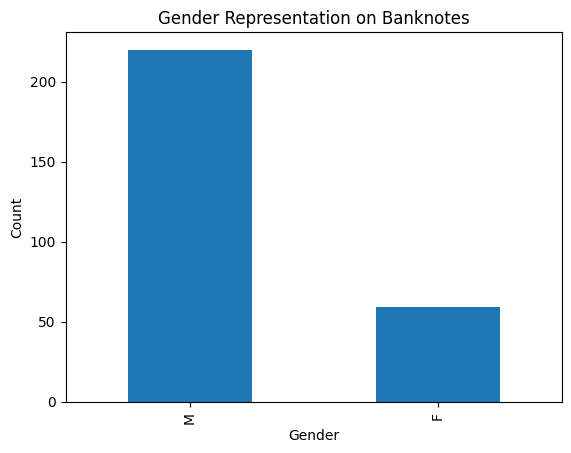

In [61]:
gender_counts = df['gender'].value_counts()

gender_counts.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Representation on Banknotes')
plt.show()

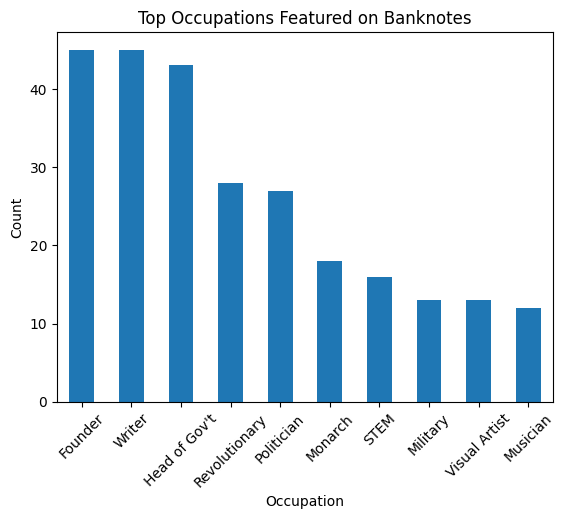

In [62]:
occupation_counts = df['occupation'].value_counts().head(10)

occupation_counts.plot(kind='bar')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.title('Top Occupations Featured on Banknotes')
plt.xticks(rotation=45)
plt.show()

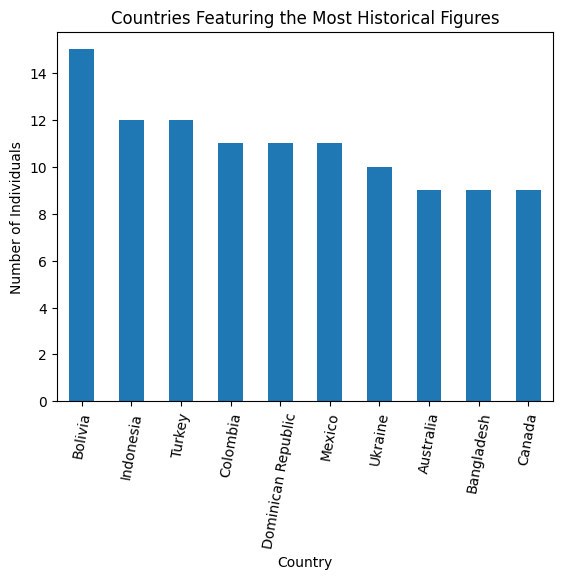

In [66]:
country_counts = df['country'].value_counts().head(10)

country_counts.plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Number of Individuals')
plt.title('Countries Featuring the Most Historical Figures')
plt.xticks(rotation=80)
plt.show()

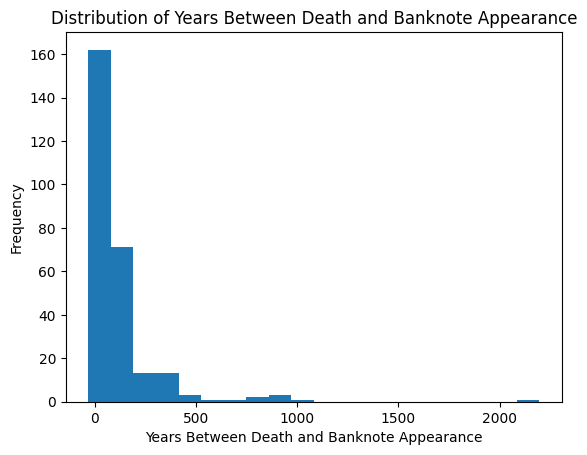

In [64]:
df['first_death_diff'].plot(kind='hist', bins=20)

plt.xlabel('Years Between Death and Banknote Appearance')
plt.ylabel('Frequency')
plt.title('Distribution of Years Between Death and Banknote Appearance')
plt.show()

# Conclusion
# Key Insights
<pre>
• Male figures dominate representation on banknotes.
• Politicians and writers are among the most common occupations.
• Some individuals appear on currency more than a century after their death.
• Countries vary significantly in the historical eras they highlight.
This analysis demonstrates how currency reflects cultural memory and national identity.
<pre>